# Solar Energy Production Forecasting
## Machine Learning Time-Series Project

**Author:** Layan Mousa

### Project objective
This notebook forecasts solar-energy production using a valid chronological machine-learning workflow. It preserves time order, prevents target leakage, creates lag and rolling features from historical solar-production observations, compares multiple regression models with a naive persistence baseline, applies time-series cross-validation, analyzes residuals and feature importance, tunes the final Random Forest model, and saves the complete preprocessing-and-model pipeline.

### Dataset
Expected file name: `Energy Production Dataset.csv`

Expected columns:
`Date`, `Start_Hour`, `End_Hour`, `Source`, `Day_of_Year`, `Day_Name`, `Month_Name`, `Season`, and `Production`.

# 1. Import Libraries

In [1]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

In [30]:
# Define project output directories

current_directory = Path.cwd()

project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)

images_directory = project_root / "images"
models_directory = project_root / "models"

images_directory.mkdir(parents=True, exist_ok=True)
models_directory.mkdir(parents=True, exist_ok=True)

print("Images directory:", images_directory.resolve())
print("Models directory:", models_directory.resolve())

Images directory: C:\Users\TraineePC1\Downloads\Renewable-Energy---Forecasting\images
Models directory: C:\Users\TraineePC1\Downloads\Renewable-Energy---Forecasting\models


# 2. Load and Inspect Dataset
The dataset is loaded once. The following checks cover its shape, columns, data types, missing values, duplicates, and descriptive statistics.

In [2]:
candidate_paths = [
    Path("../data/Energy Production Dataset.csv"),   
    Path("data/Energy Production Dataset.csv"),       
    Path("Energy Production Dataset.csv"),         
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Energy Production Dataset.csv was not found.\n"
        "Place the CSV file inside the data/ folder."
    )

print(f"Dataset path: {data_path.resolve()}")

df = pd.read_csv(data_path)

# Keep solar-energy observations only
df["Source"] = df["Source"].astype(str).str.strip()

df = (
    df[df["Source"].str.lower() == "solar"]
    .copy()
    .reset_index(drop=True)
)

if df.empty:
    raise ValueError(
        "No solar-energy records were found in the dataset."
    )

print("Selected energy source: Solar")
print("Solar observations:", len(df))

display(df.head())

Dataset path: C:\Users\TraineePC1\Downloads\Renewable-Energy---Forecasting\data\Energy Production Dataset.csv
Selected energy source: Solar
Solar observations: 9378


,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,11/26/2025,12,13,Solar,330,Wednesday,November,Fall,7050
1,11/26/2025,13,14,Solar,330,Wednesday,November,Fall,6697
2,11/26/2025,11,12,Solar,330,Wednesday,November,Fall,6772
3,11/26/2025,14,15,Solar,330,Wednesday,November,Fall,5715
4,11/18/2025,11,12,Solar,322,Tuesday,November,Fall,7764


# 3. Data Quality Assessment
Exact duplicate rows are removed only once. Outliers are reviewed later rather than deleted automatically, because unusually high production may be a valid operational event.

In [3]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_removed = rows_before - len(df)

print("Exact duplicate rows removed:", rows_removed)
print("Rows remaining:", len(df))

Exact duplicate rows removed: 0
Rows remaining: 9378


# 4. Chronological Sorting
`Date` is converted to a datetime value. The solar observations are then sorted by date and start hour before any lag or rolling feature is created.

In [4]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

invalid_dates = df["Date"].isna().sum()
if invalid_dates:
    print("Rows removed because Date could not be parsed:", invalid_dates)

df = df.dropna(subset=["Date"])

df = (
    df.sort_values(["Date", "Start_Hour"])
      .reset_index(drop=True)
)

print("Date range:", df["Date"].min(), "to", df["Date"].max())
display(df[["Source", "Date", "Start_Hour", "Production"]].head())

Date range: 2020-01-01 00:00:00 to 2025-11-26 00:00:00


,Source,Date,Start_Hour,Production
0,Solar,2020-01-01,12,2544
1,Solar,2020-01-01,13,2179
2,Solar,2020-01-01,14,1783
3,Solar,2020-01-05,11,3282
4,Solar,2020-01-05,12,3338


# 5. Exploratory Data Analysis
The visualizations below focus on forecasting patterns. Each chart is followed by a short interpretation.

## 5.1 Monthly Production Pattern

,Average Production
Month_Number,
1,"3,946.5394"
2,"5,865.7057"
3,"6,129.7349"
4,"5,919.8182"
5,"6,016.4468"
6,"5,565.0634"
7,"6,411.4619"
8,"6,193.0934"
9,"5,488.6683"


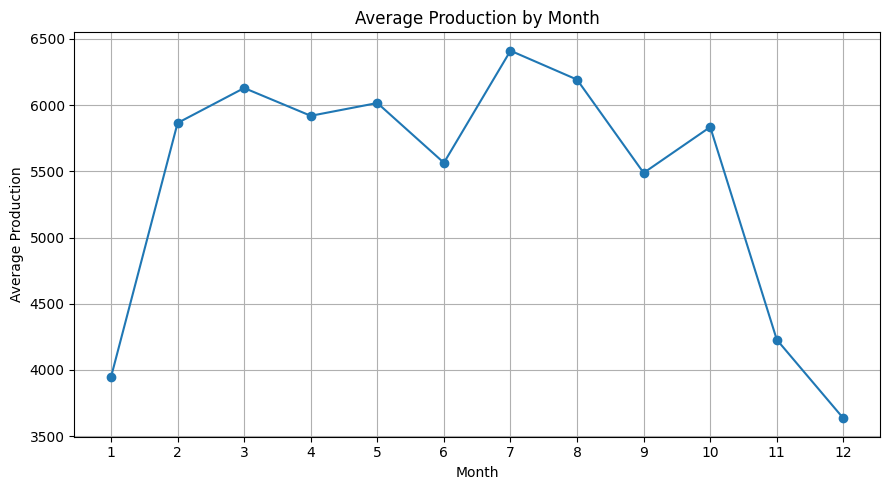

In [5]:
monthly_production = (
    df.assign(Month_Number=df["Date"].dt.month)
      .groupby("Month_Number")["Production"]
      .mean()
)

display(monthly_production.to_frame("Average Production"))

monthly_production.plot(kind="line", marker="o", figsize=(9, 5))
plt.title("Average Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:** The monthly pattern indicates whether production has annual seasonality. Because month is cyclical, sine and cosine encodings are added later so December and January remain close in feature space.

# 5.2. Solar Production Distribution by Month

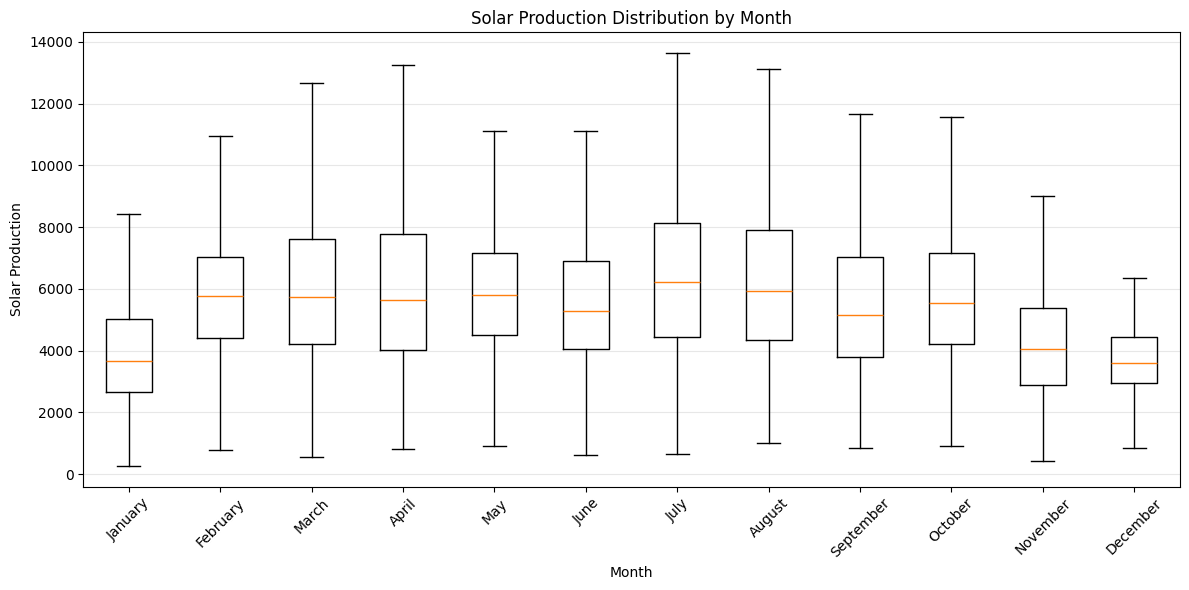

In [6]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

solar_monthly_data = [
    df.loc[df["Month_Name"] == month, "Production"].dropna()
    for month in month_order
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    solar_monthly_data,
    tick_labels=month_order,
    showfliers=False,
)

plt.title("Solar Production Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Solar Production")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Time Feature Engineering
Time-derived variables are created once. Cyclical encodings preserve the circular relationship of month and day of week.

In [7]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

df["Month_Sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_Cos"] = np.cos(2 * np.pi * df["Month"] / 12)
df["DayOfWeek_Sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
df["DayOfWeek_Cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

display(
    df[
        [
            "Date", "Year", "Month", "Day", "DayOfWeek", "IsWeekend",
            "Month_Sin", "Month_Cos", "DayOfWeek_Sin", "DayOfWeek_Cos"
        ]
    ].head()
)

,Date,Year,Month,Day,DayOfWeek,IsWeekend,Month_Sin,Month_Cos,DayOfWeek_Sin,DayOfWeek_Cos
0,2020-01-01,2020,1,1,2,0,0.5000,0.8660,0.9749,-0.2225
1,2020-01-01,2020,1,1,2,0,0.5000,0.8660,0.9749,-0.2225
2,2020-01-01,2020,1,1,2,0,0.5000,0.8660,0.9749,-0.2225
3,2020-01-05,2020,1,5,6,1,0.5000,0.8660,-0.7818,0.6235
4,2020-01-05,2020,1,5,6,1,0.5000,0.8660,-0.7818,0.6235


# 7. Lag and Rolling Features
Lag features are created from the chronologically ordered solar-production series. The rolling mean uses `shift(1)` before `rolling(3)`, preventing the current target value from leaking into its own predictors.

In [8]:
# Create leakage-safe historical features for solar production

df["Lag_1"] = df["Production"].shift(1)

df["Lag_2"] = df["Production"].shift(2)

df["Rolling_Mean_3"] = (
    df["Production"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

required_history_features = [
    "Lag_1",
    "Lag_2",
    "Rolling_Mean_3",
]

rows_before_filtering = len(df)

df = (
    df.dropna(subset=required_history_features)
    .reset_index(drop=True)
)

print(
    "Rows removed due to insufficient historical data:",
    rows_before_filtering - len(df),
)

display(
    df[
        [
            "Date",
            "Start_Hour",
            "Production",
            "Lag_1",
            "Lag_2",
            "Rolling_Mean_3",
        ]
    ].head()
)

Rows removed due to insufficient historical data: 3


,Date,Start_Hour,Production,Lag_1,Lag_2,Rolling_Mean_3
0,2020-01-05,11,3282,"1,783.0000","2,179.0000","2,168.6667"
1,2020-01-05,12,3338,"3,282.0000","1,783.0000","2,414.6667"
2,2020-01-05,13,3227,"3,338.0000","3,282.0000","2,801.0000"
3,2020-01-05,14,2952,"3,227.0000","3,338.0000","3,282.3333"
4,2020-01-05,15,2299,"2,952.0000","3,227.0000","3,172.3333"


# 8. Define Features and Target
Categorical features remain readable strings. Redundant text columns such as `Month_Name` and `Day_Name` are excluded because equivalent numerical and cyclical features are already available.

In [9]:
feature_columns = [
    "Start_Hour",
    "End_Hour",
    "Season",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "IsWeekend",
    "Month_Sin",
    "Month_Cos",
    "DayOfWeek_Sin",
    "DayOfWeek_Cos",
    "Lag_1",
    "Lag_2",
    "Rolling_Mean_3",
]

X = df[feature_columns].copy()
y = df["Production"].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())

Features shape: (9375, 15)
Target shape: (9375,)


,Start_Hour,End_Hour,Season,Year,Month,Day,DayOfWeek,IsWeekend,Month_Sin,Month_Cos,DayOfWeek_Sin,DayOfWeek_Cos,Lag_1,Lag_2,Rolling_Mean_3
0,11,12,Winter,2020,1,5,6,1,0.5000,0.8660,-0.7818,0.6235,"1,783.0000","2,179.0000","2,168.6667"
1,12,13,Winter,2020,1,5,6,1,0.5000,0.8660,-0.7818,0.6235,"3,282.0000","1,783.0000","2,414.6667"
2,13,14,Winter,2020,1,5,6,1,0.5000,0.8660,-0.7818,0.6235,"3,338.0000","3,282.0000","2,801.0000"
3,14,15,Winter,2020,1,5,6,1,0.5000,0.8660,-0.7818,0.6235,"3,227.0000","3,338.0000","3,282.3333"
4,15,16,Winter,2020,1,5,6,1,0.5000,0.8660,-0.7818,0.6235,"2,952.0000","3,227.0000","3,172.3333"


# 9. Chronological Train-Test Split
The first 80% of observations are used for training and the latest 20% for testing. No random split or shuffling is used in the final forecasting evaluation.

In [10]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

train_dates = df["Date"].iloc[:split_index].copy()
test_dates = df["Date"].iloc[split_index:].copy()

assert train_dates.max() <= test_dates.min(), (
    "Chronological split failed: "
    "the training period overlaps with the future test period."
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print(
    "Training period:",
    train_dates.min(),
    "to",
    train_dates.max(),
)

print(
    "Testing period:",
    test_dates.min(),
    "to",
    test_dates.max(),
)

print("Chronological split verification passed.")

Training samples: 7500
Testing samples: 1875
Training period: 2020-01-05 00:00:00 to 2024-10-30 00:00:00
Testing period: 2024-10-30 00:00:00 to 2025-11-26 00:00:00
Chronological split verification passed.


## 9.1 Chronological Split Visualization

The chart below shows that the model is trained using earlier observations and evaluated only on the latest future period.

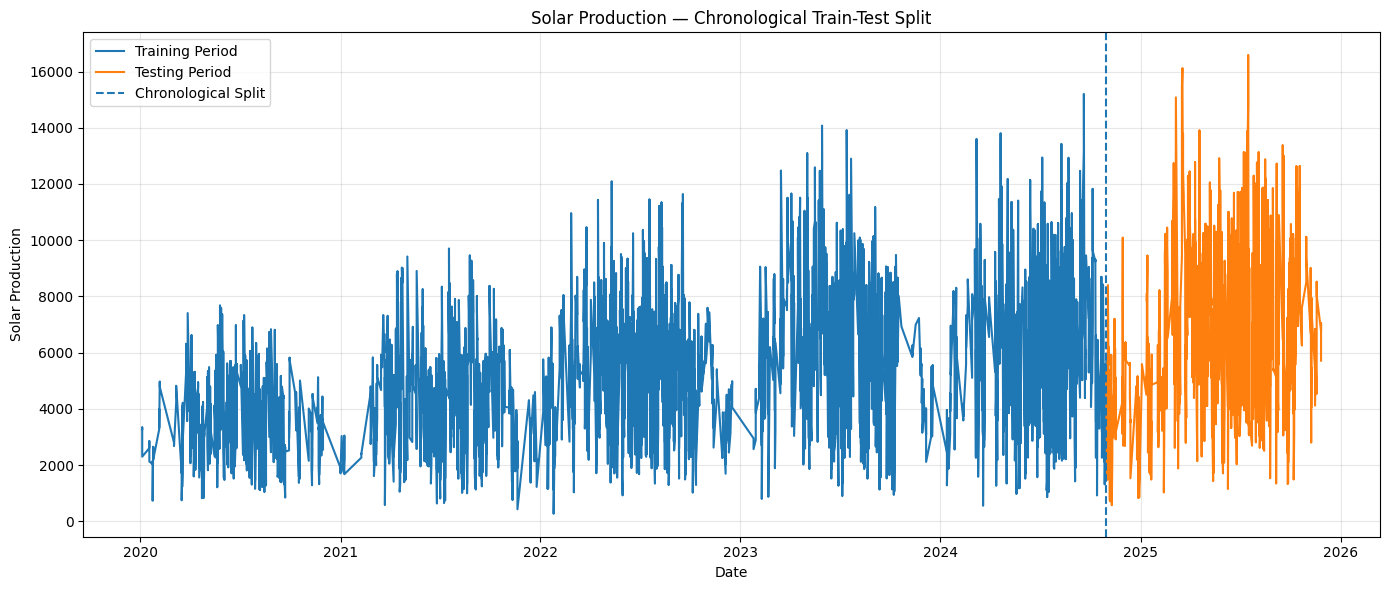

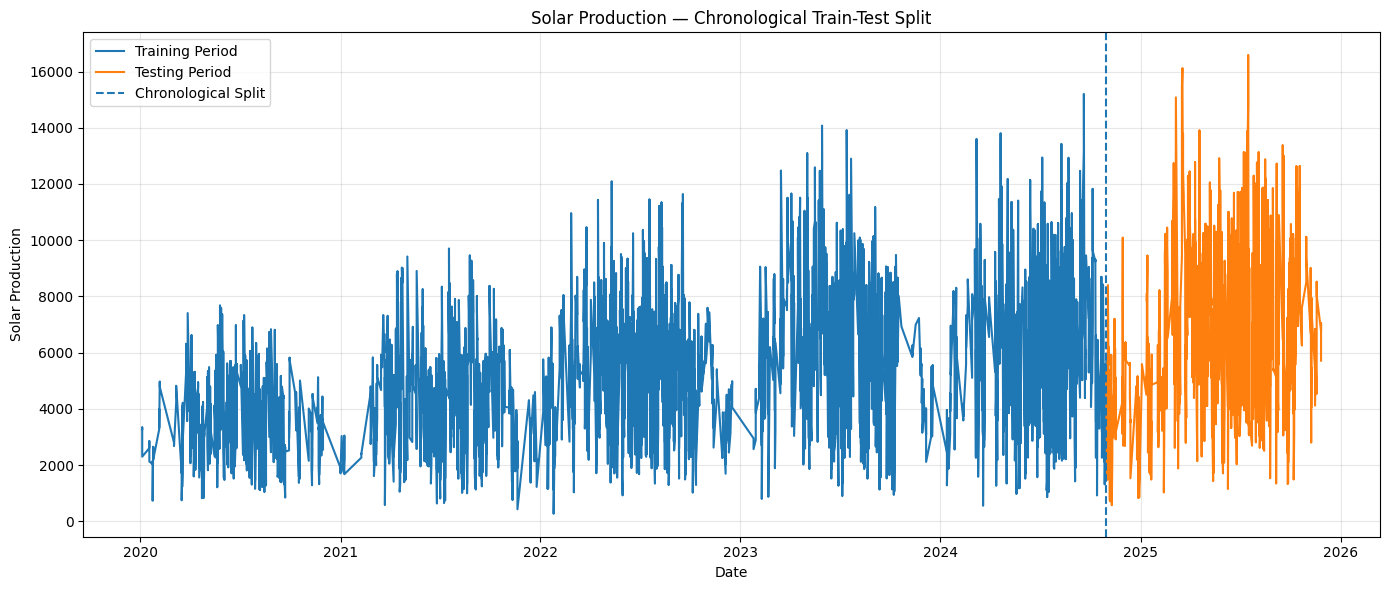

In [32]:

split_date = test_dates.min()

plt.figure(figsize=(14, 6))

plt.plot(
    train_dates,
    y_train,
    label="Training Period",
)

plt.plot(
    test_dates,
    y_test,
    label="Testing Period",
)

plt.axvline(
    split_date,
    linestyle="--",
    label="Chronological Split",
)

plt.title("Solar Production — Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Solar Production")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
split_date = test_dates.min()

plt.figure(figsize=(14, 6))

plt.plot(
    train_dates,
    y_train,
    label="Training Period",
)

plt.plot(
    test_dates,
    y_test,
    label="Testing Period",
)

plt.axvline(
    split_date,
    linestyle="--",
    label="Chronological Split",
)

plt.title("Solar Production — Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Solar Production")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    images_directory / "chronological_train_test_split.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.show()

# 10. Preprocessing Pipeline
Numerical and categorical columns use separate preprocessing steps. All preprocessing is fitted only through the model pipeline on training folds, preventing leakage.

In [12]:
numerical_features = [
    "Start_Hour",
    "End_Hour",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "IsWeekend",
    "Month_Sin",
    "Month_Cos",
    "DayOfWeek_Sin",
    "DayOfWeek_Cos",
    "Lag_1",
    "Lag_2",
    "Rolling_Mean_3",
]

categorical_features = [
    "Season",
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features),
])

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 14
Categorical features: 1


# 11. Naive Persistence Baseline
The persistence baseline predicts that the next production value will equal the previous value from the same source (`Lag_1`). A useful forecasting model should outperform this simple benchmark.

In [13]:
naive_predictions = X_test["Lag_1"]

naive_mae = mean_absolute_error(y_test, naive_predictions)
naive_rmse = mean_squared_error(y_test, naive_predictions) ** 0.5
naive_r2 = r2_score(y_test, naive_predictions)

naive_results = pd.DataFrame([{
    "Model": "Naive Persistence",
    "MAE": naive_mae,
    "RMSE": naive_rmse,
    "R2": naive_r2,
}])

display(naive_results)

,Model,MAE,RMSE,R2
0,Naive Persistence,"1,176.1909","1,697.0214",0.6248


# 12. Model Creation
Three regression pipelines are compared using identical preprocessing.

In [14]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeRegressor(
            max_depth=8,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
        ),
    ),
])

forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        ),
    ),
])

models = {
    "Linear Regression": linear_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": forest_pipeline,
}

print("Models:", list(models))

Models: ['Linear Regression', 'Decision Tree', 'Random Forest']


# 13. Time-Series Cross-Validation
`TimeSeriesSplit` preserves order inside each validation fold. Lower MAE and RMSE indicate smaller forecast errors, while a lower RMSE standard deviation indicates more stable performance across time periods.

In [15]:
time_series_cv = TimeSeriesSplit(n_splits=5)
cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=time_series_cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "mse": "neg_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=-1,
    )

    fold_mae = -scores["test_mae"]
    fold_rmse = np.sqrt(-scores["test_mse"])
    fold_r2 = scores["test_r2"]

    cv_results.append({
        "Model": model_name,
        "Mean CV MAE": fold_mae.mean(),
        "Mean CV RMSE": fold_rmse.mean(),
        "Mean CV R2": fold_r2.mean(),
        "RMSE Std": fold_rmse.std(),
    })

cv_results_df = (
    pd.DataFrame(cv_results)
      .sort_values("Mean CV RMSE")
      .reset_index(drop=True)
)

display(cv_results_df)

best_cv_row = cv_results_df.iloc[0]
most_stable_row = cv_results_df.sort_values("RMSE Std").iloc[0]

print("Lowest mean CV RMSE:", best_cv_row["Model"])
print("Lowest RMSE standard deviation:", most_stable_row["Model"])
print(
    "Time-series cross-validation is more realistic than random folds because "
    "each validation fold occurs after its corresponding training observations."
)

,Model,Mean CV MAE,Mean CV RMSE,Mean CV R2,RMSE Std
0,Random Forest,462.3037,762.6309,0.8663,129.9694
1,Decision Tree,574.9103,879.8804,0.8204,115.3363
2,Linear Regression,823.0377,"1,250.3439",0.6427,203.1198


Lowest mean CV RMSE: Random Forest
Lowest RMSE standard deviation: Decision Tree
Time-series cross-validation is more realistic than random folds because each validation fold occurs after its corresponding training observations.


# 14. Test Evaluation and Model Comparison
Every model is fitted on the same chronological training period and evaluated on the same untouched future test period.

In [16]:
test_results = []
test_predictions_by_model = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    test_predictions_by_model[model_name] = predictions

    test_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
        "R2": r2_score(y_test, predictions),
    })

test_results_df = (
    pd.DataFrame(test_results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

comparison_results_df = pd.concat(
    [naive_results, test_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

display(comparison_results_df)

best_model_name = test_results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
best_predictions = best_model.predict(X_test)

best_test_row = test_results_df.iloc[0]

print("Best baseline ML model:", best_model_name)
print(
    "Does the best baseline ML model beat the naive baseline?",
    bool(best_test_row["RMSE"] < naive_rmse),
)

,Model,MAE,RMSE,R2
0,Random Forest,753.0552,"1,265.3325",0.7914
1,Decision Tree,904.5339,"1,371.9671",0.7548
2,Linear Regression,"1,094.7564","1,569.9473",0.6789
3,Naive Persistence,"1,176.1909","1,697.0214",0.6248


Best baseline ML model: Random Forest
Does the best baseline ML model beat the naive baseline? True


## 14.1 Model Performance Comparison

The following chart compares the persistence baseline and all trained machine-learning models using RMSE on the untouched future test period. Lower RMSE indicates better forecasting performance.

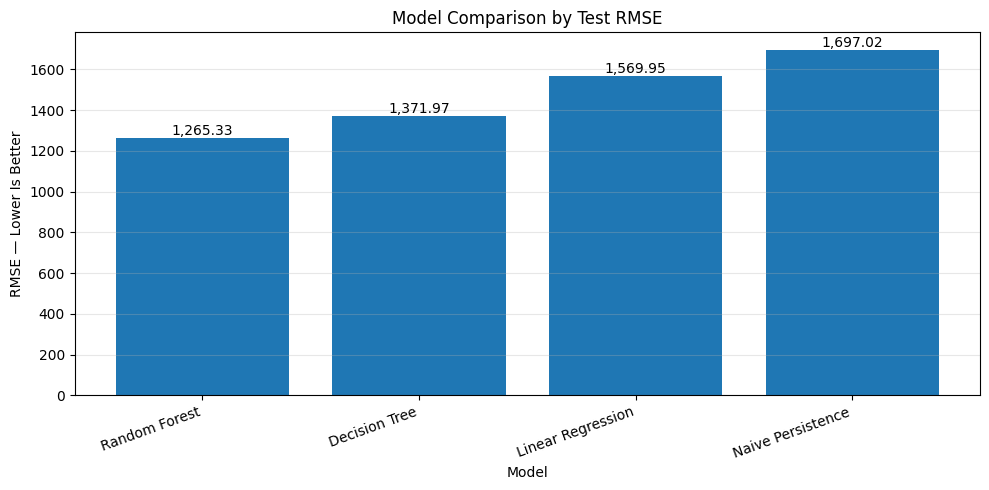

In [17]:
# Compare all models using test RMSE

model_comparison_plot = (
    comparison_results_df
    .sort_values("RMSE", ascending=True)
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    model_comparison_plot["Model"],
    model_comparison_plot["RMSE"],
)

plt.title("Model Comparison by Test RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE — Lower Is Better")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, model_comparison_plot["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.2f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

# 15. Chronological Actual-versus-Predicted Plot
Predictions are plotted against real dates, not shuffled row numbers.

In [18]:
# Prepare comparison dataframe for visualization

comparison_df = pd.DataFrame({
    "Date": test_dates.values,
    "Actual Production": y_test.values,
    "Predicted Production": best_predictions,
})

comparison_df = (
    comparison_df
    .sort_values("Date")
    .reset_index(drop=True)
)

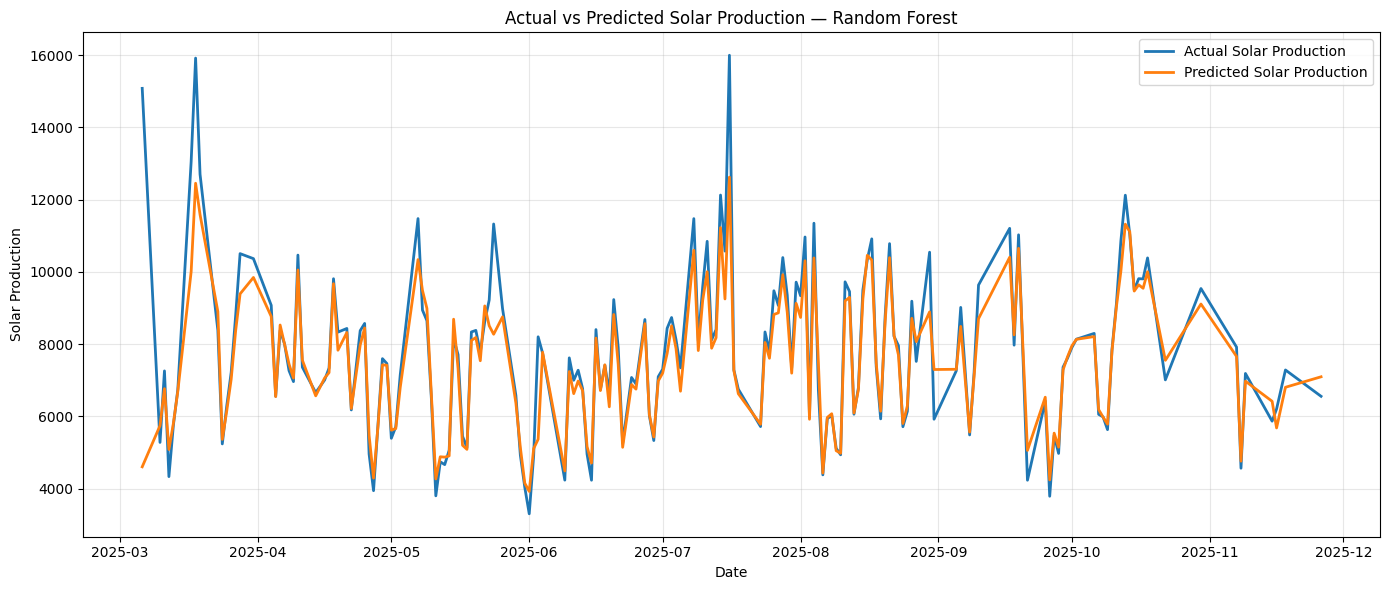

C:\Users\TraineePC1\AppData\Local\Temp\ipykernel_25648\1222013137.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


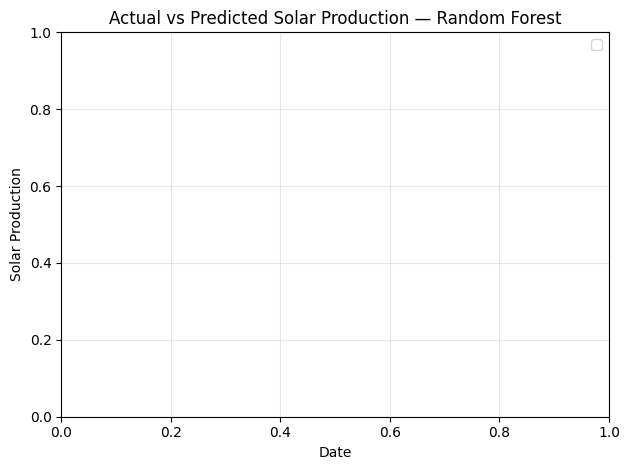

In [ ]:

# Aggregate observations by date for a clearer visualization

daily_comparison = (
    comparison_df
    .groupby("Date", as_index=False)
    .mean(numeric_only=True)
)

plot_window = daily_comparison.tail(180)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_window["Date"],
    plot_window["Actual Production"],
    label="Actual Solar Production",
    linewidth=2,
)

plt.plot(
    plot_window["Date"],
    plot_window["Predicted Production"],
    label="Predicted Solar Production",
    linewidth=2,
)

plt.title(
    f"Actual vs Predicted Solar Production — {best_model_name}"
)
plt.xlabel("Date")
plt.ylabel("Solar Production")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 16. Solar Forecast Performance by Month

,Month,MAE,RMSE,R2
0,1,554.4609,869.5156,0.7880
1,2,546.5419,935.5893,0.8378
2,3,930.8944,"1,699.3571",0.6981
3,4,876.5426,"1,463.2667",0.5379
4,5,"1,072.0898","1,638.9339",0.5453
5,6,944.8860,"1,464.3364",0.6083
6,7,597.5922,996.7043,0.8677
7,8,683.1188,"1,110.9283",0.8314
8,9,621.3681,"1,222.3860",0.8101
9,10,537.4980,721.8704,0.9187


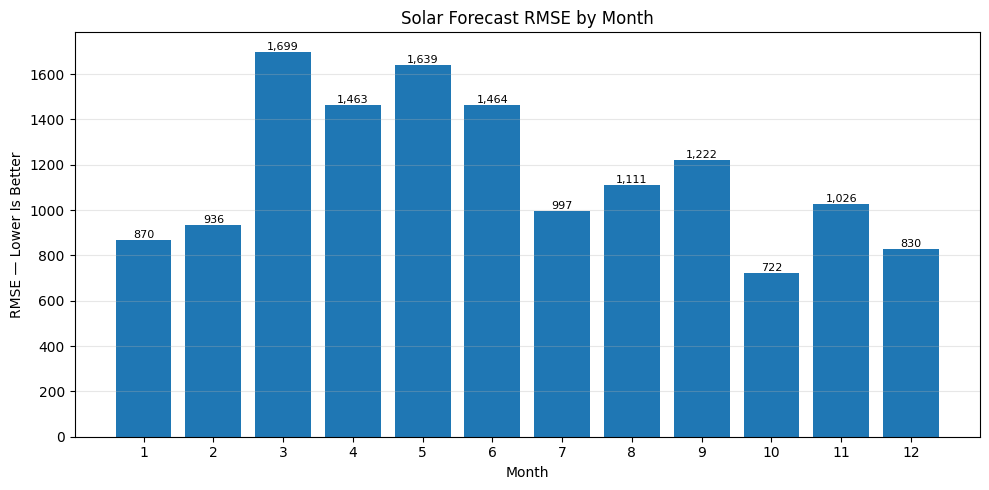

In [20]:
monthly_performance_df = comparison_df.copy()

monthly_performance_df["Month"] = (
    monthly_performance_df["Date"].dt.month
)

monthly_performance_rows = []

for month, group in monthly_performance_df.groupby("Month"):
    monthly_performance_rows.append({
        "Month": month,
        "MAE": mean_absolute_error(
            group["Actual Production"],
            group["Predicted Production"],
        ),
        "RMSE": mean_squared_error(
            group["Actual Production"],
            group["Predicted Production"],
        ) ** 0.5,
        "R2": r2_score(
            group["Actual Production"],
            group["Predicted Production"],
        ),
    })

monthly_performance = pd.DataFrame(
    monthly_performance_rows
).sort_values("Month")

display(monthly_performance)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    monthly_performance["Month"].astype(str),
    monthly_performance["RMSE"],
)

plt.title("Solar Forecast RMSE by Month")
plt.xlabel("Month")
plt.ylabel("RMSE — Lower Is Better")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(
    bars,
    monthly_performance["RMSE"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

# 17. Residual Analysis
Residuals are calculated as `actual − predicted`. A reliable model should have residuals distributed around zero without a strong visible pattern.

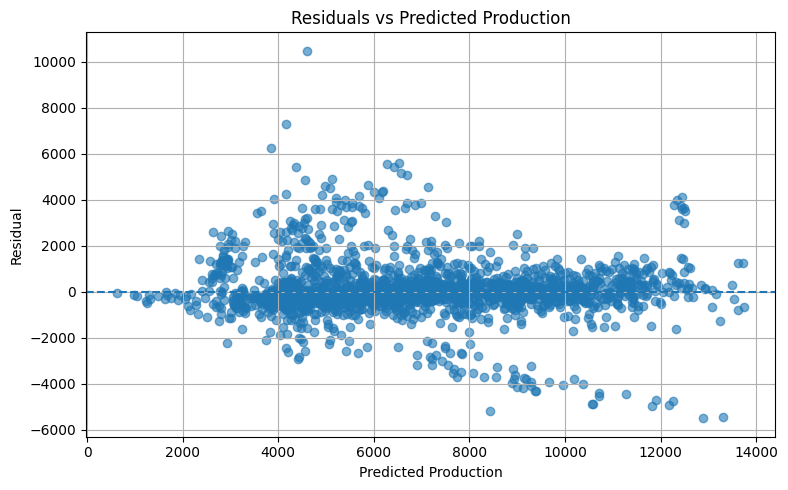

In [21]:
residuals = y_test.values - best_predictions

plt.figure(figsize=(8, 5))
plt.scatter(best_predictions, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted Production")
plt.xlabel("Predicted Production")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

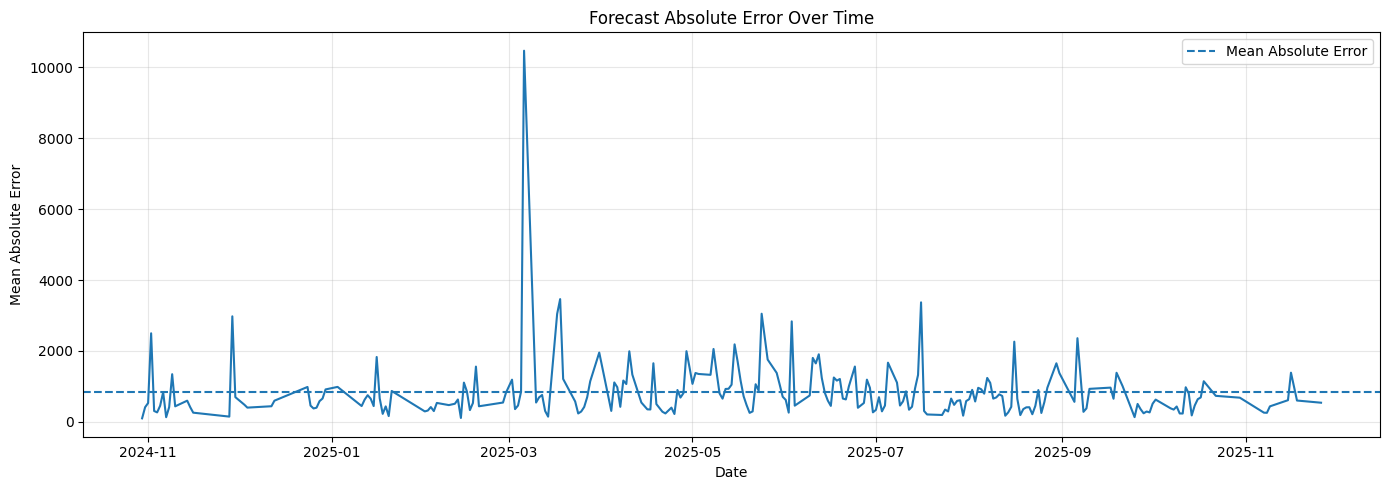

,Residual
count,"1,875.0000"
mean,93.1994
std,"1,262.2321"
min,"-5,503.7187"
25%,-365.1684
50%,-37.4303
75%,429.9495
max,"10,472.8621"


Mean residual: 93.19936996529051
Median residual: -37.43031403504938
Overall mean absolute residual: 753.0552223403467
Mean absolute residual in highest 10% of predictions: 870.7238305889799
Residuals show a noticeable average bias away from zero.
Errors increase at high predicted production values.
Review the scatter plot for curves, funnels, or clusters. These patterns can reveal non-linearity, changing error variance, or time-dependent behavior.


In [22]:
error_over_time_df = comparison_df.copy()

error_over_time_df["Absolute Error"] = np.abs(
    error_over_time_df["Actual Production"]
    - error_over_time_df["Predicted Production"]
)

daily_error = (
    error_over_time_df.groupby("Date", as_index=False)[
        "Absolute Error"
    ]
    .mean()
    .sort_values("Date")
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_error["Date"],
    daily_error["Absolute Error"],
)

plt.axhline(
    daily_error["Absolute Error"].mean(),
    linestyle="--",
    label="Mean Absolute Error",
)

plt.title("Forecast Absolute Error Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

residual_summary = pd.Series(residuals).describe()
display(residual_summary.to_frame("Residual"))

high_prediction_threshold = np.quantile(best_predictions, 0.90)
high_error_mae = np.mean(
    np.abs(residuals[best_predictions >= high_prediction_threshold])
)
overall_error_mae = np.mean(np.abs(residuals))

print("Mean residual:", residuals.mean())
print("Median residual:", np.median(residuals))
print("Overall mean absolute residual:", overall_error_mae)
print("Mean absolute residual in highest 10% of predictions:", high_error_mae)

if abs(residuals.mean()) <= 0.05 * np.std(residuals):
    print("Residuals are approximately centered around zero.")
else:
    print("Residuals show a noticeable average bias away from zero.")

if high_error_mae > overall_error_mae:
    print("Errors increase at high predicted production values.")
else:
    print("Errors do not clearly increase at high predicted production values.")

print(
    "Review the scatter plot for curves, funnels, or clusters. "
    "These patterns can reveal non-linearity, changing error variance, or time-dependent behavior."
)

# 18. Overfitting Check
Training and testing RMSE are compared for the selected baseline model.

In [23]:
train_predictions = best_model.predict(X_train)
test_predictions = best_model.predict(X_test)

train_rmse = mean_squared_error(y_train, train_predictions) ** 0.5
test_rmse = mean_squared_error(y_test, test_predictions) ** 0.5
rmse_difference = test_rmse - train_rmse

print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)
print("RMSE Difference:", rmse_difference)

if test_rmse <= train_rmse * 1.15:
    print("Interpretation: Training and testing errors are reasonably similar.")
elif train_rmse < test_rmse:
    print("Interpretation: The lower training error suggests possible overfitting.")
else:
    print("Interpretation: Review the split and data distribution because test error is unexpectedly lower.")

Training RMSE: 386.0003347272379
Testing RMSE: 1265.3324881408403
RMSE Difference: 879.3321534136023
Interpretation: The lower training error suggests possible overfitting.


# 19. Hyperparameter Tuning
Random Forest is tuned only after clean baselines and time-series cross-validation have been established. The full parameter grid follows the feedback plan exactly.

> This grid evaluates 32 parameter combinations across five time-series folds, resulting in 160 model fits. The search may take several minutes.

In [24]:
parameter_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [8, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.8],
}

grid_search = GridSearchCV(
    estimator=forest_pipeline,
    param_grid=parameter_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV RMSE:")
print(-grid_search.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters:
{'model__max_depth': None, 'model__max_features': 0.8, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Best CV RMSE:
755.1761338655896


,Model,MAE,RMSE,R2
0,Tuned Random Forest,744.7997,"1,257.8699",0.7939
1,Random Forest,753.0552,"1,265.3325",0.7914
2,Decision Tree,904.5339,"1,371.9671",0.7548
3,Linear Regression,"1,094.7564","1,569.9473",0.6789
4,Naive Persistence,"1,176.1909","1,697.0214",0.6248


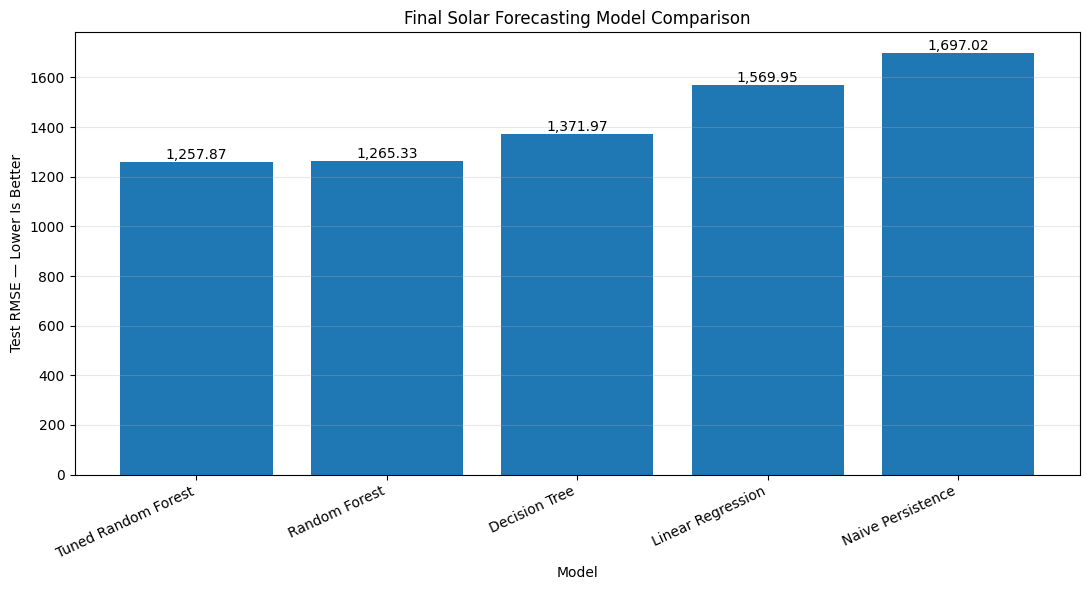

Tuned model beats naive baseline: True
Tuned model improves over baseline Random Forest: True


In [25]:
tuned_model = grid_search.best_estimator_
tuned_predictions = tuned_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_rmse = mean_squared_error(y_test, tuned_predictions) ** 0.5
tuned_r2 = r2_score(y_test, tuned_predictions)

tuned_results = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "MAE": tuned_mae,
    "RMSE": tuned_rmse,
    "R2": tuned_r2,
}])

final_comparison_df = pd.concat(
    [naive_results, test_results_df, tuned_results],
    ignore_index=True,
).sort_values("RMSE").reset_index(drop=True)

display(final_comparison_df)

# Compare the naive baseline, baseline models, and tuned model

final_model_comparison_plot = (
    final_comparison_df
    .sort_values("RMSE", ascending=True)
    .reset_index(drop=True)
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    final_model_comparison_plot["Model"],
    final_model_comparison_plot["RMSE"],
)

plt.title("Final Solar Forecasting Model Comparison")
plt.xlabel("Model")
plt.ylabel("Test RMSE — Lower Is Better")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(
    bars,
    final_model_comparison_plot["RMSE"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.2f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()

plt.savefig(
    images_directory / "final_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Tuned model beats naive baseline:", tuned_rmse < naive_rmse)
print(
    "Tuned model improves over baseline Random Forest:",
    tuned_rmse
    < test_results_df.loc[
        test_results_df["Model"] == "Random Forest", "RMSE"
      ].iloc[0],
)

# 20. Feature Importance
Feature names are extracted from the complete tuned pipeline. The top features are displayed and interpreted rather than merely plotted.

,Readable Feature,Importance
0,Lag 1,0.6641
1,End Hour,0.0903
2,Start Hour,0.0891
3,Rolling Mean 3,0.0801
4,Lag 2,0.0356
5,Year,0.0131
6,Month Cos,0.0068
7,Day,0.0061
8,Month,0.0037
9,DayOfWeek Sin,0.0025


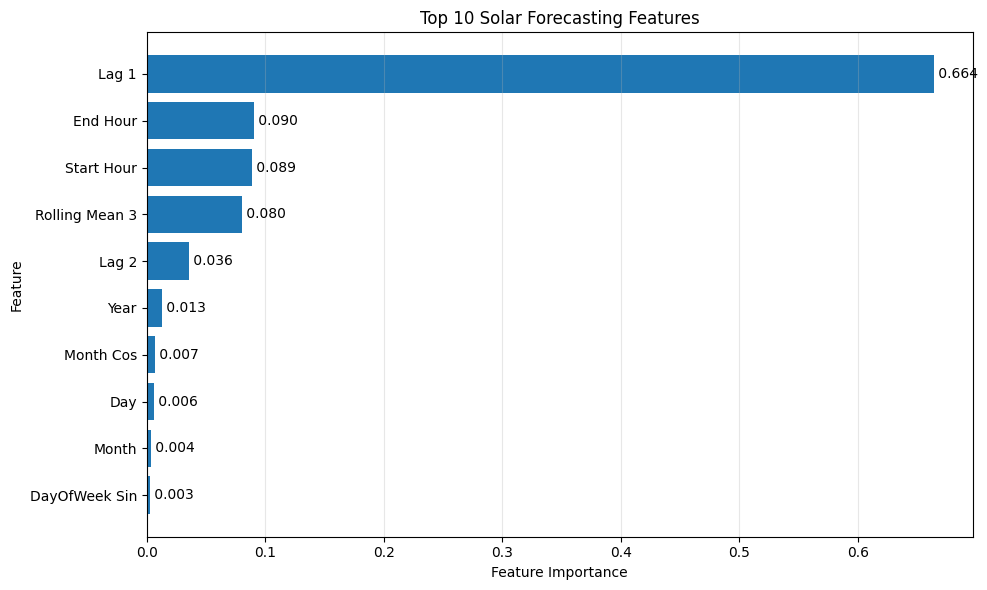

In [26]:
final_model = tuned_model

feature_names = (
    final_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importances = (
    final_model.named_steps["model"]
    .feature_importances_
)

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": feature_importances,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

importance_df["Readable Feature"] = (
    importance_df["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

top_features = importance_df.head(10)

display(
    top_features[
        ["Readable Feature", "Importance"]
    ]
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_features["Readable Feature"][::-1],
    top_features["Importance"][::-1],
)

plt.title("Top 10 Solar Forecasting Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)

for bar, value in zip(
    bars,
    top_features["Importance"][::-1],
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.3f}",
        va="center",
    )

plt.tight_layout()
plt.show()

In [27]:
def feature_group_importance(prefix_or_name):
    mask = importance_df["Feature"].str.contains(
        prefix_or_name,
        regex=False,
    )
    return importance_df.loc[mask, "Importance"].sum()


lag_importance = (
    feature_group_importance("Lag_1")
    + feature_group_importance("Lag_2")
)

rolling_importance = feature_group_importance(
    "Rolling_Mean_3"
)

season_importance = feature_group_importance("Season")

hour_importance = (
    feature_group_importance("Start_Hour")
    + feature_group_importance("End_Hour")
)

calendar_importance = (
    feature_group_importance("Year")
    + feature_group_importance("Month")
    + feature_group_importance("Day")
    + feature_group_importance("DayOfWeek")
    + feature_group_importance("IsWeekend")
)

feature_group_summary = pd.DataFrame({
    "Feature Group": [
        "Lag Features",
        "Rolling Mean",
        "Hour Features",
        "Calendar Features",
        "Season",
    ],
    "Importance": [
        lag_importance,
        rolling_importance,
        hour_importance,
        calendar_importance,
        season_importance,
    ],
}).sort_values(
    "Importance",
    ascending=False,
).reset_index(drop=True)

display(feature_group_summary)

print(
    "Most important individual feature:",
    importance_df.iloc[0]["Readable Feature"],
)

print(
    "Features with near-zero importance:",
    importance_df.loc[
        importance_df["Importance"] < 0.001,
        "Readable Feature",
    ].tolist(),
)

,Feature Group,Importance
0,Lag Features,0.6996
1,Hour Features,0.1795
2,Rolling Mean,0.0801
3,Calendar Features,0.0456
4,Season,0.0018


Most important individual feature: Lag 1
Features with near-zero importance: ['Season Summer', 'Season Fall', 'Season Spring', 'Season Winter', 'IsWeekend']


**Interpretation:** Lag and rolling variables represent recent solar-production history and are expected to be strong predictors. Seasonal, hourly, and calendar variables capture recurring temporal patterns in solar-energy generation. Features with nearly zero importance may add little predictive value and can be reviewed in future feature-selection experiments.

# 21. Save Final Pipeline
The complete tuned pipeline is saved, keeping preprocessing and the Random Forest estimator together.

In [28]:
model_output_path = (
    Path("../models")
    / "solar_energy_forecasting_pipeline.joblib"
)

model_output_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

joblib.dump(
    tuned_model,
    model_output_path,
)

print(
    "Saved solar forecasting pipeline to:",
    model_output_path.resolve(),
)

Saved solar forecasting pipeline to: C:\Users\TraineePC1\Downloads\Renewable-Energy---Forecasting\models\solar_energy_forecasting_pipeline.joblib


# 22. Final Conclusion and Limitations
The following cell generates a conclusion using the actual results from this run.

In [29]:
best_cv_model_name = cv_results_df.iloc[0]["Model"]
best_cv_rmse = cv_results_df.iloc[0]["Mean CV RMSE"]

tuned_train_predictions = tuned_model.predict(X_train)
tuned_train_rmse = mean_squared_error(
    y_train,
    tuned_train_predictions,
) ** 0.5

tuned_rmse_gap = tuned_rmse - tuned_train_rmse
top_three_features = importance_df.head(3)["Feature"].tolist()

beats_naive_text = "does" if tuned_rmse < naive_rmse else "does not"
overfit_text = (
    "shows a potentially meaningful train-test gap"
    if tuned_rmse > tuned_train_rmse * 1.15
    else "shows a reasonably controlled train-test gap"
)

conclusion = f'''
The tuned Random Forest was evaluated on a chronological future holdout period.
The naive persistence baseline achieved an RMSE of {naive_rmse:,.2f}.
The strongest baseline model in time-series cross-validation was
{best_cv_model_name}, with a mean CV RMSE of {best_cv_rmse:,.2f}.

On the untouched test period, the tuned Random Forest achieved:
- MAE: {tuned_mae:,.2f}
- RMSE: {tuned_rmse:,.2f}
- R²: {tuned_r2:.4f}

The tuned model {beats_naive_text} outperform the naive persistence forecast.
Its training RMSE was {tuned_train_rmse:,.2f}, and its test RMSE was
{tuned_rmse:,.2f}; therefore, it {overfit_text}.

The three most important transformed features were:
{", ".join(top_three_features)}.

Limitations:
1. This is a short-horizon supervised forecasting experiment based mainly on
   historical production and calendar variables.
2. Weather variables, maintenance events, demand constraints, and equipment
   availability are not included.
3. The chronological holdout provides one future-period test; additional
   walk-forward evaluation would strengthen the evidence.
4. Longer lag windows, weather variables, and solar-specific models may improve
forecast accuracy.
'''

print(conclusion)


The tuned Random Forest was evaluated on a chronological future holdout period.
The naive persistence baseline achieved an RMSE of 1,697.02.
The strongest baseline model in time-series cross-validation was
Random Forest, with a mean CV RMSE of 762.63.

On the untouched test period, the tuned Random Forest achieved:
- MAE: 744.80
- RMSE: 1,257.87
- R²: 0.7939

The tuned model does outperform the naive persistence forecast.
Its training RMSE was 342.30, and its test RMSE was
1,257.87; therefore, it shows a potentially meaningful train-test gap.

The three most important transformed features were:
numeric__Lag_1, numeric__End_Hour, numeric__Start_Hour.

Limitations:
1. This is a short-horizon supervised forecasting experiment based mainly on
   historical production and calendar variables.
2. Weather variables, maintenance events, demand constraints, and equipment
   availability are not included.
3. The chronological holdout provides one future-period test; additional
   walk-forward ev